In [5]:
import os

try:
    from IPython.display import display
except ImportError:
    display = print

import pandas as pd
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

import matplotlib.pyplot as plt
import numpy as np
import ast
from itertools import combinations
import networkx as nx
from collections import Counter

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

RAW_DATA_PATH = os.path.join(DATA_DIR, "data_merged.csv")
CLEAN_VACANCIES_PATH = os.path.join(DATA_DIR, "data_clean.csv")
REMOVED_POSTS_PATH = os.path.join(DATA_DIR, "data_removed.csv")
FINAL_DATASET_PATH = os.path.join(DATA_DIR, "vacancies_dataset.csv")

,До фильтрации,После фильтрации
channel,,
Design Hunters,3565,2354
Digital Jobster,5205,2655
ВДХЛ,21938,11953


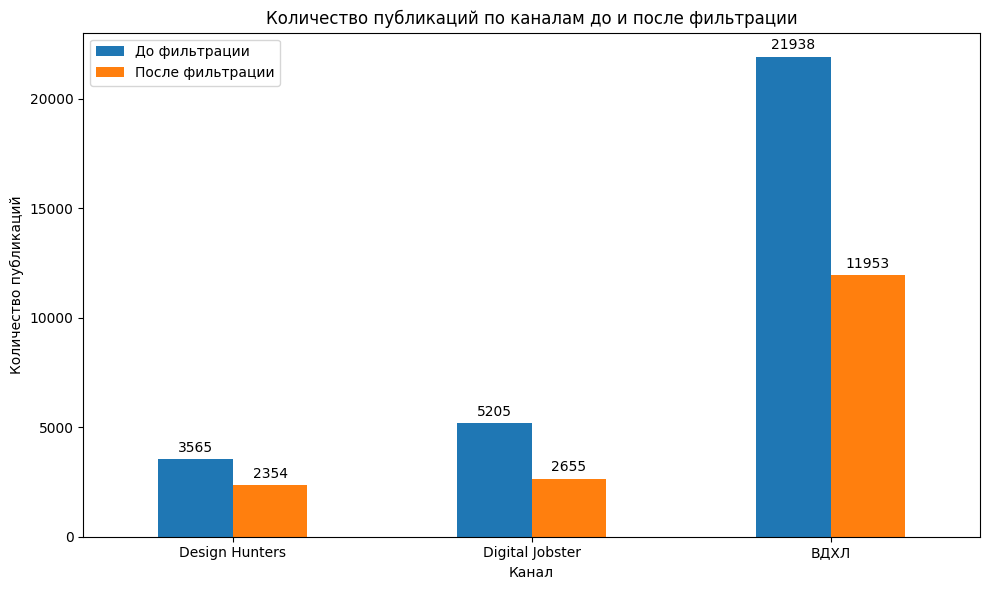

In [6]:
df_raw = pd.read_csv(RAW_DATA_PATH)
df_vacancies = pd.read_csv(CLEAN_VACANCIES_PATH)

before_counts = (
    df_raw.groupby("channel")
          .size()
          .rename("До фильтрации")
)

after_counts = (
    df_vacancies.groupby("channel")
                .size()
                .rename("После фильтрации")
)

plot_df = pd.concat(
    [before_counts, after_counts],
    axis=1
).fillna(0)

channel_names = {
    "vdhl_good": "ВДХЛ",
    "designhunters": "Design Hunters",
    "digital_jobster": "Digital Jobster"
}

plot_df.index = plot_df.index.map(channel_names)

plot_df = plot_df.astype(int)

display(plot_df)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Количество публикаций по каналам до и после фильтрации")
ax.set_xlabel("Канал")
ax.set_ylabel("Количество публикаций")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,count,share
profession_pretty,,
Маркетинг / SMM / PR,3798,22.391227
Копирайтинг,3713,21.890107
Дизайн,3534,20.834807
Видео / Продюсирование,1926,11.354793
Менеджмент,1144,6.744488
Другое,1064,6.272845
Администрирование,971,5.724561
Business development,535,3.154109
IT / аналитика,149,0.878434


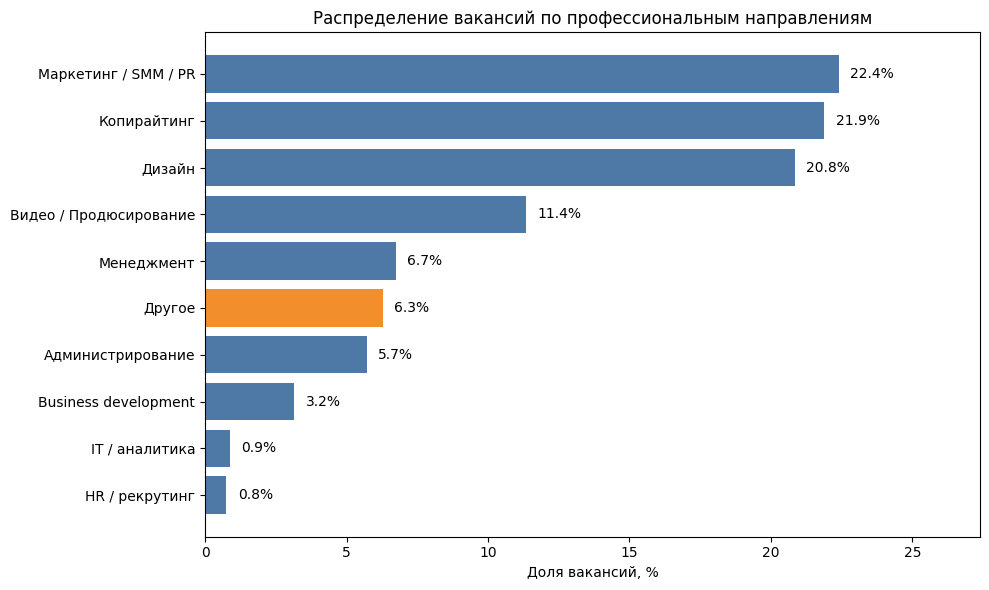

In [7]:
df = pd.read_csv(FINAL_DATASET_PATH)

profession_names = {
    "Дизайн": "Дизайн",
    "Маркетинг / SMM / PR": "Маркетинг / SMM / PR",
    "Контент / редактура / копирайтинг": "Копирайтинг",
    "Продюсирование / видео / production": "Видео / Продюсирование",
    "Администрирование / ассистенты": "Администрирование",
    "Project / product / account management": "Менеджмент",
    "Продажи / business development": "Business development",
    "IT / аналитика": "IT / аналитика",
    "HR / рекрутинг": "HR / рекрутинг",
    "Другое": "Другое"
}

df["profession_pretty"] = df["profession"].replace(profession_names)

profession_counts = (
    df["profession_pretty"]
    .value_counts()
    .sort_values(ascending=True)
)

profession_share = profession_counts / profession_counts.sum() * 100

plot_df = pd.DataFrame({
    "count": profession_counts,
    "share": profession_share
})

display(plot_df.sort_values("count", ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "#f28e2b" if profession == "Другое" else "#4e79a7"
    for profession in plot_df.index
]

bars = ax.barh(
    plot_df.index,
    plot_df["share"],
    color=colors
)

for bar, profession, share in zip(
    bars,
    plot_df.index,
    plot_df["share"]
):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{share:.1f}%",
        va="center",
        fontsize=10
    )

ax.set_title("Распределение вакансий по профессиональным направлениям")
ax.set_xlabel("Доля вакансий, %")
ax.set_ylabel("")

ax.set_xlim(0, plot_df["share"].max() + 5)

plt.tight_layout()
plt.show()

Период анализа: 2023 - 2026 г.
Количество вакансий за последние 3 года: 7208


Дизайн


,skill,count,share
0,Figma,602,43.092341
1,Photoshop,454,32.498210
2,Illustrator,391,27.988547
3,After Effects,152,10.880458
4,InDesign,136,9.735147
5,Tilda,74,5.297065
6,Яндекс Метрика,73,5.225483




Маркетинг / SMM / PR


,skill,count,share
0,Яндекс Метрика,325,17.444981
1,CRM,208,11.164788
2,SEO,124,6.655931
3,Figma,121,6.494901
4,Excel,115,6.172840
5,Canva,74,3.972088
6,Photoshop,60,3.220612




Контент / Копирайтинг


,skill,count,share
0,SEO,73,5.320700
1,Яндекс Метрика,65,4.737609
2,Photoshop,59,4.300292
3,Figma,43,3.134111
4,Excel,34,2.478134
5,HTML,17,1.239067
6,Midjourney,15,1.093294




Видео / Продюсирование


,skill,count,share
0,After Effects,67,8.111380
1,Photoshop,64,7.748184
2,Premiere Pro,36,4.358354
3,Яндекс Метрика,31,3.753027
4,Figma,30,3.631961
5,CapCut,28,3.389831
6,Excel,25,3.026634


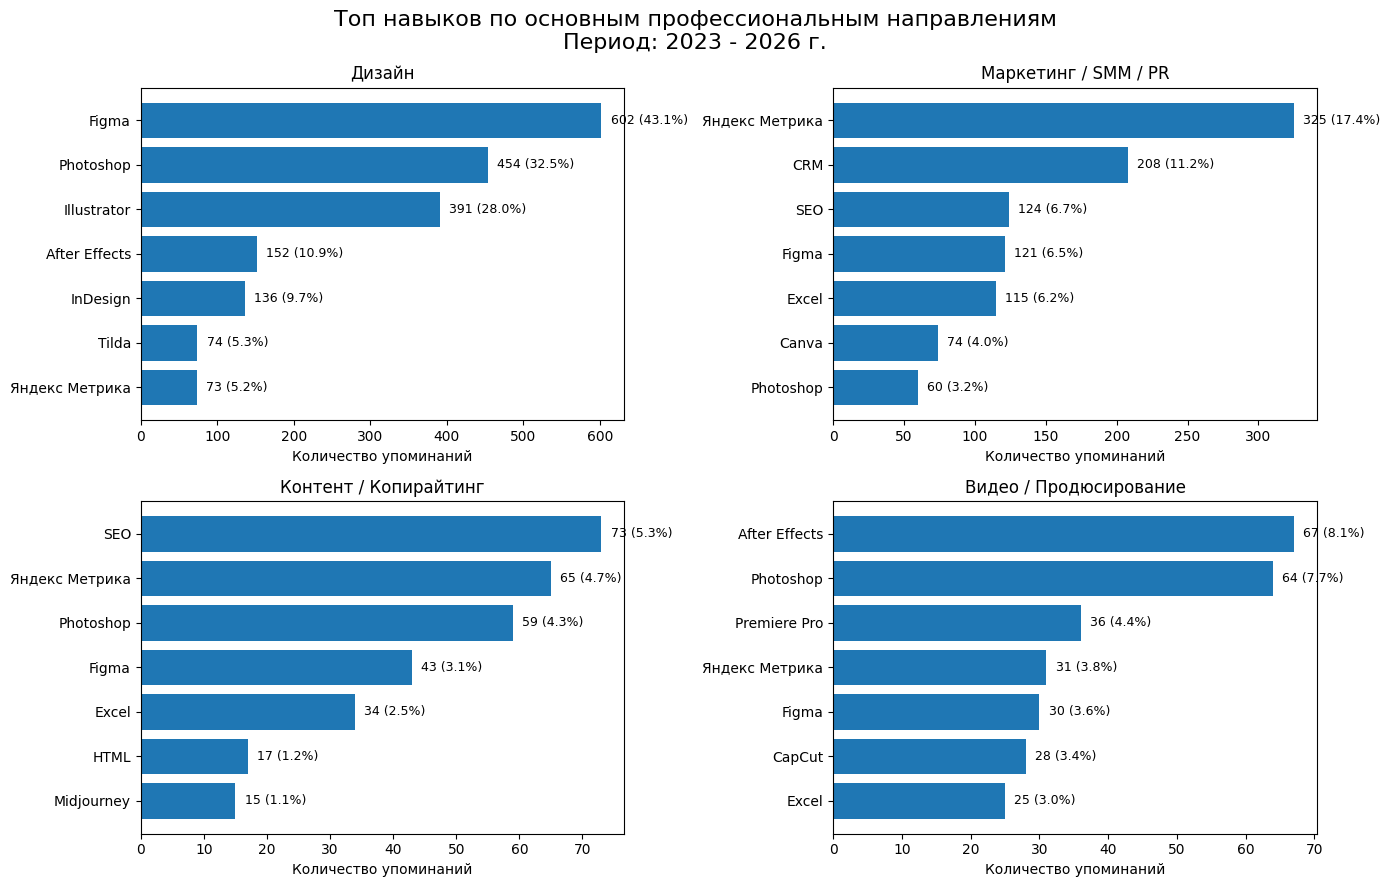

In [8]:
# Загрузка данных
df = pd.read_csv(FINAL_DATASET_PATH)

# Дата
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)

max_date = df["date"].max()
start_date = max_date - pd.DateOffset(years=3)

df = df[
    (df["date"] >= start_date)
    & (df["date"] <= max_date)
].copy()

period_text = (
    f"{start_date.strftime('%Y')} - {max_date.strftime('%Y')} г."
)

print(f"Период анализа: {period_text}")
print(f"Количество вакансий за последние 3 года: {len(df)}")


# Красивые названия профессий
profession_names = {
    "Дизайн": "Дизайн",
    "Маркетинг / SMM / PR": "Маркетинг / SMM / PR",
    "Контент / редактура / копирайтинг": "Контент / Копирайтинг",
    "Продюсирование / видео / production": "Видео / Продюсирование",
    "Администрирование / ассистенты": "Администрирование",
    "Project / product / account management": "Менеджмент",
    "Продажи / business development": "Business development",
    "IT / аналитика": "IT / аналитика",
    "HR / рекрутинг": "HR / рекрутинг",
    "Другое": "Другое"
}

df["profession_pretty"] = df["profession"].replace(profession_names)


# Восстановление списка навыков после чтения из CSV
def restore_skills(value):
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    value = str(value).strip()

    if value in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, list):
            return [
                str(skill).strip()
                for skill in parsed
                if str(skill).strip()
            ]

    except Exception:
        return []

    return []


df["skills"] = df["skills"].apply(restore_skills)


# Основные профессиональные направления для сравнения
top_professions = [
    "Дизайн",
    "Маркетинг / SMM / PR",
    "Контент / Копирайтинг",
    "Видео / Продюсирование",
]


# Подготовка таблиц с топами навыков
top_skills_tables = {}

for profession in top_professions:
    subset = df[df["profession_pretty"] == profession]

    counter = Counter()

    for skills in subset["skills"]:
        counter.update(skills)

    top_skills = pd.DataFrame(
        counter.most_common(7),
        columns=["skill", "count"]
    )

    top_skills["share"] = (
        top_skills["count"] / len(subset) * 100
        if len(subset) > 0
        else 0
    )

    top_skills_tables[profession] = top_skills


# Текстовый вывод данных
for profession, table in top_skills_tables.items():
    print("\n")
    print("=" * 80)
    print(profession)
    print("=" * 80)

    display(table)


# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, profession in zip(axes, top_professions):
    top_skills = top_skills_tables[profession].sort_values(
        "count",
        ascending=True
    )

    if top_skills.empty:
        ax.set_title(profession)
        ax.text(
            0.5,
            0.5,
            "Нет данных",
            ha="center",
            va="center",
            fontsize=12
        )
        ax.axis("off")
        continue

    bars = ax.barh(
        top_skills["skill"],
        top_skills["count"]
    )

    ax.set_title(profession)
    ax.set_xlabel("Количество упоминаний")
    ax.set_ylabel("")

    max_count = top_skills["count"].max()

    for bar, count, share in zip(
        bars,
        top_skills["count"],
        top_skills["share"]
    ):
        ax.text(
            bar.get_width() + max_count * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{count} ({share:.1f}%)",
            va="center",
            fontsize=9
        )

plt.suptitle(
    f"Топ навыков по основным профессиональным направлениям\n"
    f"Период: {period_text}",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [9]:
df = pd.read_csv(FINAL_DATASET_PATH)

def restore_skills(value):
    try:
        return ast.literal_eval(value)
    except:
        return []

df["skills"] = df["skills"].apply(restore_skills)

pair_counter = Counter()

for skills in df["skills"]:

    skills = sorted(set(skills))

    for pair in combinations(skills, 2):
        pair_counter[pair] += 1

pairs_df = pd.DataFrame(
    pair_counter.items(),
    columns=["pair", "count"]
)

pairs_df = pairs_df.sort_values(
    "count",
    ascending=False
)

display(pairs_df.head(30))

,pair,count
148,"(Illustrator, Photoshop)",890
104,"(Figma, Photoshop)",559
146,"(Figma, Illustrator)",409
22,"(After Effects, Photoshop)",378
264,"(InDesign, Photoshop)",346
262,"(Illustrator, InDesign)",316
158,"(After Effects, Illustrator)",267
91,"(After Effects, Figma)",180
60,"(Figma, Tilda)",141
45,"(Google Analytics, Яндекс Метрика)",134


Абсолютная матрица совместной встречаемости


,Figma,Photoshop,Яндекс Метрика,CRM,Illustrator,Excel,After Effects,SEO,InDesign,Canva,Tilda,Midjourney,Blender,CapCut,Cinema 4D
Figma,805,345,93,21,255,23,114,13,83,64,61,57,41,31,37
Photoshop,345,666,26,8,418,19,158,12,146,47,34,49,55,24,57
Яндекс Метрика,93,26,536,65,12,38,6,62,3,26,10,6,1,18,1
CRM,21,8,65,450,1,58,5,16,0,11,12,2,1,0,1
Illustrator,255,418,12,1,439,11,110,3,134,10,27,37,35,2,42
Excel,23,19,38,58,11,406,1,13,6,14,8,0,0,2,1
After Effects,114,158,6,5,110,1,227,0,30,8,9,25,46,13,50
SEO,13,12,62,16,3,13,0,219,0,6,8,1,0,2,0
InDesign,83,146,3,0,134,6,30,0,156,4,13,7,10,0,12
Canva,64,47,26,11,10,14,8,6,4,128,6,8,2,34,0


Нормализованная матрица связей навыков, Jaccard Index


,Figma,Photoshop,Яндекс Метрика,CRM,Illustrator,Excel,After Effects,SEO,InDesign,Canva,Tilda,Midjourney,Blender,CapCut,Cinema 4D
Figma,1.000000,0.306394,0.074519,0.017018,0.257836,0.019360,0.124183,0.012859,0.094533,0.073648,0.070115,0.066667,0.048066,0.036131,0.043839
Photoshop,0.306394,1.000000,0.022109,0.007220,0.608443,0.018044,0.214966,0.013746,0.215976,0.062918,0.044855,0.067680,0.078571,0.033058,0.083212
Яндекс Метрика,0.074519,0.022109,1.000000,0.070575,0.012461,0.042035,0.007926,0.089466,0.004354,0.040752,0.015337,0.009419,0.001603,0.029900,0.001637
CRM,0.017018,0.007220,0.070575,1.000000,0.001126,0.072682,0.007440,0.024502,0.000000,0.019400,0.021277,0.003604,0.001859,0.000000,0.001905
Illustrator,0.257836,0.608443,0.012461,0.001126,1.000000,0.013189,0.197842,0.004580,0.290672,0.017953,0.050186,0.072692,0.070994,0.003839,0.088795
Excel,0.019360,0.018044,0.042035,0.072682,0.013189,1.000000,0.001582,0.021242,0.010791,0.026923,0.015267,0.000000,0.000000,0.004098,0.002079
After Effects,0.124183,0.214966,0.007926,0.007440,0.197842,0.001582,1.000000,0.000000,0.084986,0.023055,0.026163,0.080906,0.170370,0.043624,0.197628
SEO,0.012859,0.013746,0.089466,0.024502,0.004580,0.021242,0.000000,1.000000,0.000000,0.017595,0.023739,0.003077,0.000000,0.006645,0.000000
InDesign,0.094533,0.215976,0.004354,0.000000,0.290672,0.010791,0.084986,0.000000,1.000000,0.014286,0.048327,0.027344,0.042553,0.000000,0.054545
Canva,0.073648,0.062918,0.040752,0.019400,0.017953,0.026923,0.023055,0.017595,0.014286,1.000000,0.024194,0.035242,0.009302,0.191011,0.000000


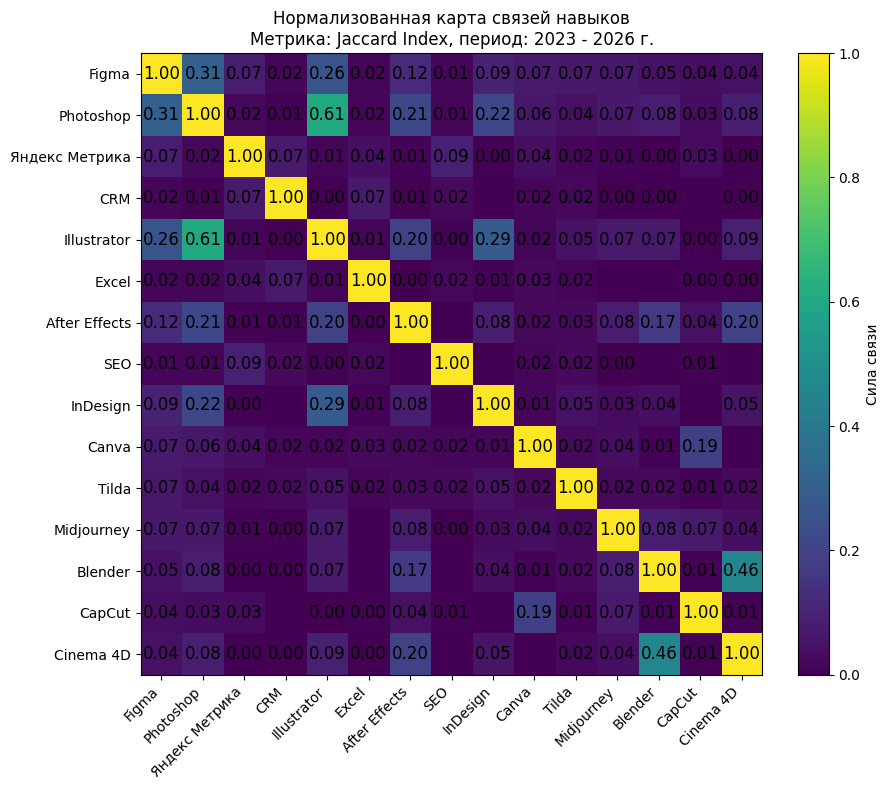

In [10]:
df = pd.read_csv(FINAL_DATASET_PATH)

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce",
    utc=True
)

max_date = df["date"].max()
start_date = max_date - pd.DateOffset(years=3)

df = df[
    (df["date"] >= start_date)
    & (df["date"] <= max_date)
].copy()

period_text = (
    f"{start_date.strftime('%Y')} - "
    f"{max_date.strftime('%Y')} г."
)


def restore_skills(value):
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    value = str(value).strip()

    if value in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, list):
            return [
                str(skill).strip()
                for skill in parsed
                if str(skill).strip()
            ]

    except Exception:
        return []

    return []

df["skills"] = df["skills"].apply(restore_skills)

skill_counter = Counter()

for skills in df["skills"]:
    skill_counter.update(set(skills))


top_skills = [
    skill
    for skill, count in skill_counter.most_common(15)
]

cooccurrence = pd.DataFrame(
    0,
    index=top_skills,
    columns=top_skills
)

for skills in df["skills"]:
    skills = sorted(set(skills))

    skills = [
        skill
        for skill in skills
        if skill in top_skills
    ]

    for skill_1, skill_2 in combinations(skills, 2):
        cooccurrence.loc[skill_1, skill_2] += 1
        cooccurrence.loc[skill_2, skill_1] += 1

    for skill in skills:
        cooccurrence.loc[skill, skill] += 1


print("Абсолютная матрица совместной встречаемости")
display(cooccurrence)

jaccard = pd.DataFrame(
    0.0,
    index=top_skills,
    columns=top_skills
)

for skill_1 in top_skills:
    for skill_2 in top_skills:
        intersection = cooccurrence.loc[
            skill_1,
            skill_2
        ]

        union = (
            skill_counter[skill_1]
            + skill_counter[skill_2]
            - intersection
        )

        if union > 0:
            jaccard.loc[
                skill_1,
                skill_2
            ] = intersection / union


print("Нормализованная матрица связей навыков, Jaccard Index")
display(jaccard)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    jaccard.values,
    vmin=0,
    vmax=jaccard.values.max()
)

ax.set_xticks(range(len(top_skills)))
ax.set_yticks(range(len(top_skills)))

ax.set_xticklabels(
    top_skills,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    top_skills
)

for i in range(len(top_skills)):
    for j in range(len(top_skills)):
        value = jaccard.iloc[i, j]

        if value > 0:
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=12
            )

ax.set_title(
    f"Нормализованная карта связей навыков\n"
    f"Метрика: Jaccard Index, период: {period_text}"
)

plt.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Сила связи"
)

plt.tight_layout()

plt.show()



Дизайн


,skill_1,skill_2,pair_count,skill_1_count,skill_2_count,jaccard
6,Illustrator,Photoshop,375,391,454,0.797872
91,CSS,HTML,25,37,35,0.531915
17,Blender,Cinema 4D,41,73,61,0.440860
2,Figma,Photoshop,274,602,454,0.350384
56,Illustrator,InDesign,129,391,136,0.324121
3,Figma,Illustrator,236,602,391,0.311757
58,InDesign,Photoshop,133,136,454,0.291028
32,ChatGPT,Midjourney,16,19,59,0.258065
16,After Effects,Photoshop,115,152,454,0.234216
15,After Effects,Illustrator,99,152,391,0.222973




Маркетинг / SMM / PR


,skill_1,skill_2,pair_count,skill_1_count,skill_2_count,jaccard
73,ChatGPT,Midjourney,10,21,16,0.370370
83,Figma,Photoshop,35,121,60,0.239726
173,Illustrator,Photoshop,14,14,60,0.233333
113,Canva,Figma,36,74,121,0.226415
123,Canva,Photoshop,22,74,60,0.196429
81,Canva,CapCut,17,74,44,0.168317
64,CapCut,Figma,19,44,121,0.130137
25,Google Analytics,SEO,19,48,124,0.124183
120,CapCut,Photoshop,11,44,60,0.118280
3,SEO,Яндекс Метрика,47,124,325,0.116915


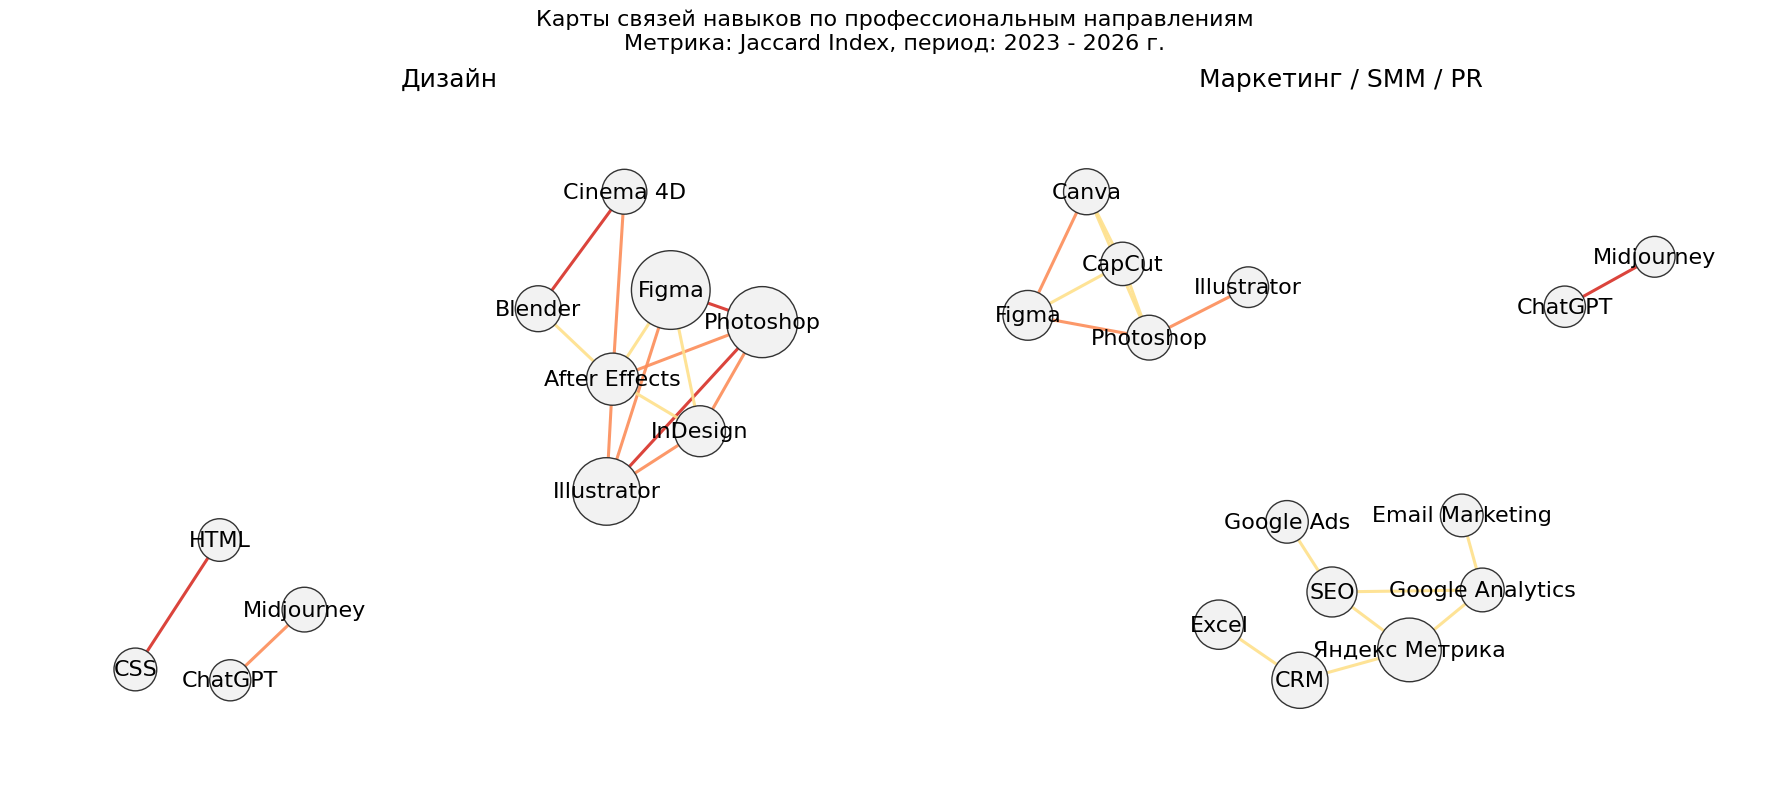



Контент / Копирайтинг


,skill_1,skill_2,pair_count,skill_1_count,skill_2_count,jaccard
36,CSS,HTML,10,10,17,0.588235
21,Figma,Photoshop,20,43,59,0.243902
44,HTML,Tilda,5,17,12,0.208333
65,Illustrator,Photoshop,9,9,59,0.152542
38,CSS,Figma,6,10,43,0.127660
4,Canva,Figma,6,14,43,0.117647
40,Figma,HTML,6,43,17,0.111111
27,Google Analytics,Яндекс Метрика,6,7,65,0.090909
57,SEO,Яндекс Метрика,10,73,65,0.078125
63,Canva,Photoshop,5,14,59,0.073529




Видео / Продюсирование


,skill_1,skill_2,pair_count,skill_1_count,skill_2_count,jaccard
38,Blender,Cinema 4D,10,12,14,0.625000
40,Blender,Python,6,12,6,0.500000
20,After Effects,Photoshop,40,67,64,0.439560
42,Cinema 4D,Python,6,14,6,0.428571
22,Canva,Figma,12,21,30,0.307692
14,After Effects,Premiere Pro,24,67,36,0.303797
21,Canva,CapCut,10,21,28,0.256410
68,Canva,Google Analytics,5,21,6,0.227273
29,Illustrator,Photoshop,15,19,64,0.220588
26,Figma,Photoshop,16,30,64,0.205128


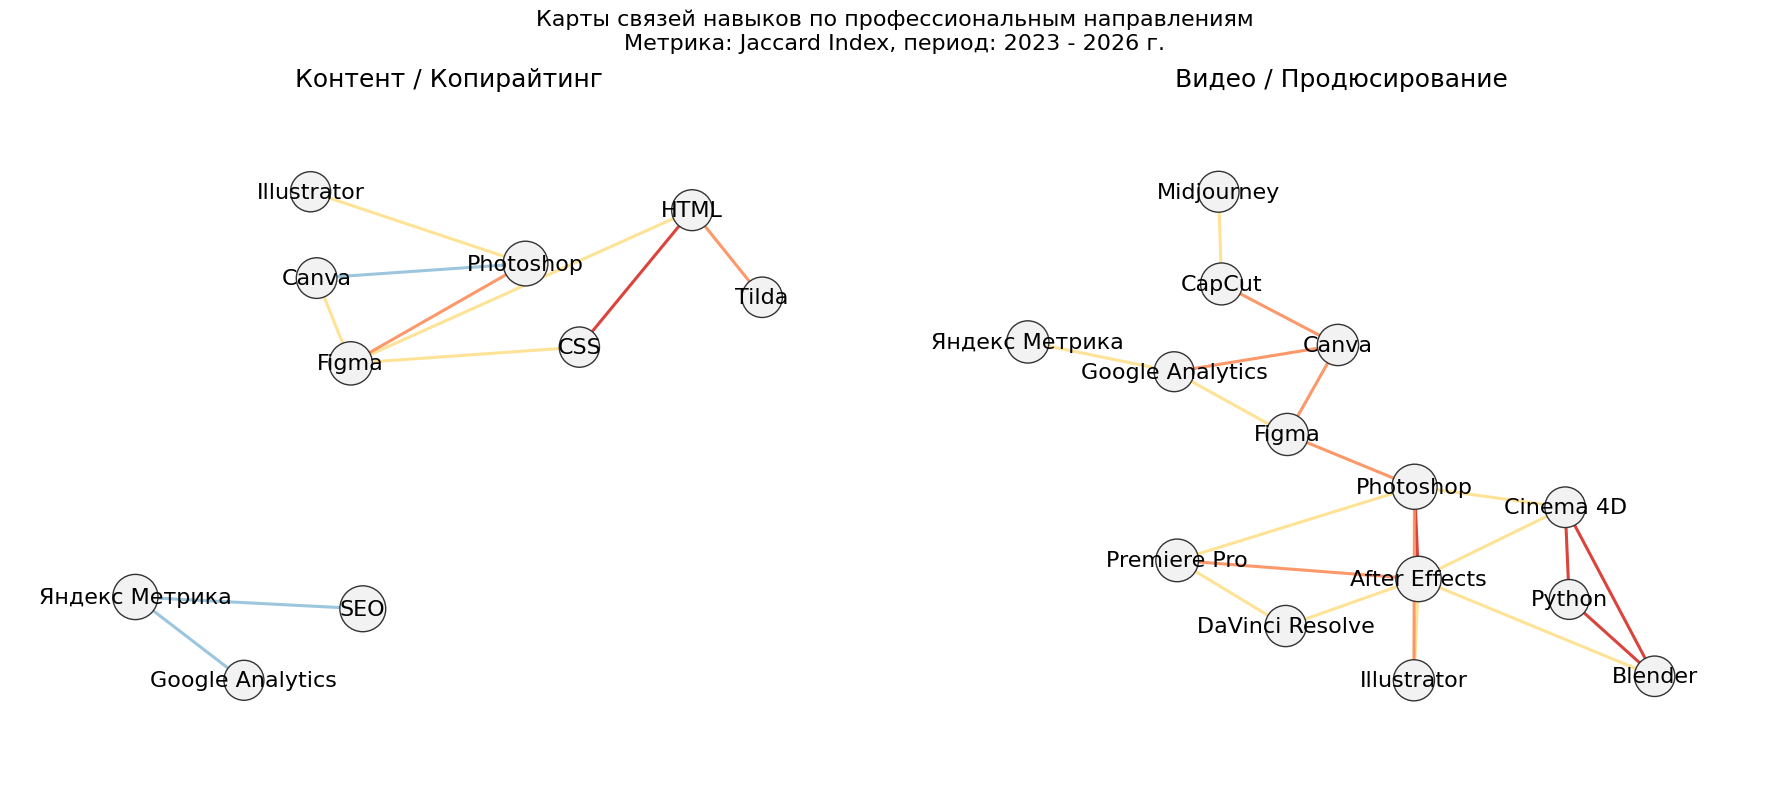

In [11]:
df = pd.read_csv(FINAL_DATASET_PATH)

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce",
    utc=True
)

max_date = df["date"].max()
start_date = max_date - pd.DateOffset(years=3)

df = df[
    (df["date"] >= start_date)
    & (df["date"] <= max_date)
].copy()

period_text = (
    f"{start_date.strftime('%Y')} - {max_date.strftime('%Y')} г."
)


profession_names = {
    "Дизайн": "Дизайн",
    "Маркетинг / SMM / PR": "Маркетинг / SMM / PR",
    "Контент / редактура / копирайтинг": "Контент / Копирайтинг",
    "Продюсирование / видео / production": "Видео / Продюсирование",
    "Администрирование / ассистенты": "Администрирование",
    "Project / product / account management": "Менеджмент",
    "Продажи / business development": "Business development",
    "IT / аналитика": "IT / аналитика",
    "HR / рекрутинг": "HR / рекрутинг",
    "Другое": "Другое"
}

df["profession_pretty"] = df["profession"].replace(profession_names)


def restore_skills(value):
    if pd.isna(value):
        return []

    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, list):
            return [
                str(skill).strip()
                for skill in parsed
                if str(skill).strip()
            ]

    except Exception:
        return []

    return []


df["skills"] = df["skills"].apply(restore_skills)


top_professions = [
    "Дизайн",
    "Маркетинг / SMM / PR",
    "Контент / Копирайтинг",
    "Видео / Продюсирование",
]


def get_edge_color(strength):
    if strength >= 0.35:
        return "#d73027"
    elif strength >= 0.20:
        return "#fc8d59"
    elif strength >= 0.10:
        return "#fee08b"
    else:
        return "#91bfdb"


graph_filters = {
    "Дизайн": {
        "min_pair_count": 10,
        "min_jaccard": 0.1,
        "top_n": 20
    },
    "Маркетинг / SMM / PR": {
        "min_pair_count": 8,
        "min_jaccard": 0.1,
        "top_n": 20
    },
    "Контент / Копирайтинг": {
        "min_pair_count": 5,
        "min_jaccard": 0.06,
        "top_n": 20
    },
    "Видео / Продюсирование": {
        "min_pair_count": 5,
        "min_jaccard": 0.04,
        "top_n": 20
    },
}


def build_skill_graph(subset, profession):
    skill_counter = Counter()
    pair_counter = Counter()

    for skills in subset["skills"]:
        skills = sorted(set(skills))

        skill_counter.update(skills)

        for pair in combinations(skills, 2):
            pair_counter[pair] += 1

    pairs_data = []

    for (skill_1, skill_2), pair_count in pair_counter.items():
        skill_1_count = skill_counter[skill_1]
        skill_2_count = skill_counter[skill_2]

        union = skill_1_count + skill_2_count - pair_count
        jaccard = pair_count / union if union > 0 else 0

        pairs_data.append({
            "skill_1": skill_1,
            "skill_2": skill_2,
            "pair_count": pair_count,
            "skill_1_count": skill_1_count,
            "skill_2_count": skill_2_count,
            "jaccard": jaccard,
        })

    pairs_df = pd.DataFrame(pairs_data)

    if pairs_df.empty:
        return nx.Graph(), skill_counter, pairs_df

    settings = graph_filters[profession]

    pairs_filtered = pairs_df[
        (pairs_df["pair_count"] >= settings["min_pair_count"])
        & (pairs_df["jaccard"] >= settings["min_jaccard"])
    ].copy()

    pairs_filtered = pairs_filtered.sort_values(
        "jaccard",
        ascending=False
    ).head(settings["top_n"])

    G = nx.Graph()

    for _, row in pairs_filtered.iterrows():
        G.add_edge(
            row["skill_1"],
            row["skill_2"],
            weight=row["pair_count"],
            strength=row["jaccard"],
            layout_weight=row["jaccard"] ** 1.5
        )

    return G, skill_counter, pairs_filtered


def improve_min_distance(pos, min_distance=0.35, max_iter=100):
    for _ in range(max_iter):
        moved = False
        nodes = list(pos.keys())

        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                node_a = nodes[i]
                node_b = nodes[j]

                x1, y1 = pos[node_a]
                x2, y2 = pos[node_b]

                dx = x2 - x1
                dy = y2 - y1

                distance = np.sqrt(dx**2 + dy**2)

                if distance < min_distance:
                    moved = True

                    if distance == 0:
                        dx = np.random.uniform(-0.01, 0.01)
                        dy = np.random.uniform(-0.01, 0.01)
                        distance = np.sqrt(dx**2 + dy**2)

                    shift = (min_distance - distance) / 2

                    ux = dx / distance
                    uy = dy / distance

                    pos[node_a] = (
                        x1 - ux * shift,
                        y1 - uy * shift
                    )

                    pos[node_b] = (
                        x2 + ux * shift,
                        y2 + uy * shift
                    )

        if not moved:
            break

    return pos


def plot_profession_networks(profession_group, file_name):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 8)
    )

    axes = axes.flatten()

    for ax, profession in zip(axes, profession_group):
        subset = df[
            df["profession_pretty"] == profession
        ].copy()

        G, skill_counter, pairs_filtered = build_skill_graph(
            subset,
            profession
        )

        print("\n")
        print("=" * 80)
        print(profession)
        print("=" * 80)

        if not pairs_filtered.empty:
            display(
                pairs_filtered[
                    [
                        "skill_1",
                        "skill_2",
                        "pair_count",
                        "skill_1_count",
                        "skill_2_count",
                        "jaccard",
                    ]
                ]
            )

        if len(G.nodes()) == 0:
            ax.text(
                0.5,
                0.5,
                "Недостаточно связей",
                ha="center",
                va="center",
                fontsize=12
            )
            ax.axis("off")
            continue

        pos = nx.spring_layout(
            G,
            seed=42,
            k=2.2,
            iterations=1000,
            scale=1,
            weight="layout_weight"
        )

        rng = np.random.default_rng(42)

        for node in pos:
            pos[node] = (
                pos[node][0] + rng.normal(0, 0.08),
                pos[node][1] + rng.normal(0, 0.08)
            )

        pos = improve_min_distance(
            pos,
            min_distance=0.35,
            max_iter=100
        )

        edge_colors = [
            get_edge_color(G[u][v]["strength"])
            for u, v in G.edges()
        ]

        node_sizes = [
            800 + skill_counter[node] * 4
            for node in G.nodes()
        ]

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_size=node_sizes,
            node_color="#f2f2f2",
            edgecolors="#333333",
            linewidths=1
        )

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edge_color=edge_colors,
            width=2.2,
            alpha=0.9
        )

        nx.draw_networkx_labels(
            G,
            pos,
            ax=ax,
            font_size=16
        )

        ax.set_title(
            f"{profession}",
            fontsize=18
        )

        x_values = [point[0] for point in pos.values()]
        y_values = [point[1] for point in pos.values()]

        x_min, x_max = min(x_values), max(x_values)
        y_min, y_max = min(y_values), max(y_values)

        x_margin = (x_max - x_min) * 0.2
        y_margin = (y_max - y_min) * 0.2

        ax.set_xlim(x_min - x_margin, x_max + x_margin)
        ax.set_ylim(y_min - y_margin, y_max + y_margin)

        ax.axis("off")

    plt.suptitle(
        f"Карты связей навыков по профессиональным направлениям\n"
        f"Метрика: Jaccard Index, период: {period_text}",
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

plot_profession_networks(
    top_professions[:2],
    "skills_network_professions_1.png"
)

plot_profession_networks(
    top_professions[2:],
    "skills_network_professions_2.png"
)

Доля вакансий с AI-навыками по годам и направлениям


,year,profession_pretty,total_vacancies,ai_vacancies,ai_share
0,2017,Видео / Продюсирование,3,0,0.000000
1,2017,Дизайн,175,0,0.000000
2,2017,Контент / Копирайтинг,1,0,0.000000
3,2017,Маркетинг / SMM / PR,2,0,0.000000
4,2018,Видео / Продюсирование,98,0,0.000000
5,2018,Дизайн,245,0,0.000000
6,2018,Контент / Копирайтинг,186,0,0.000000
7,2018,Маркетинг / SMM / PR,78,0,0.000000
8,2019,Видео / Продюсирование,141,0,0.000000
9,2019,Дизайн,258,0,0.000000


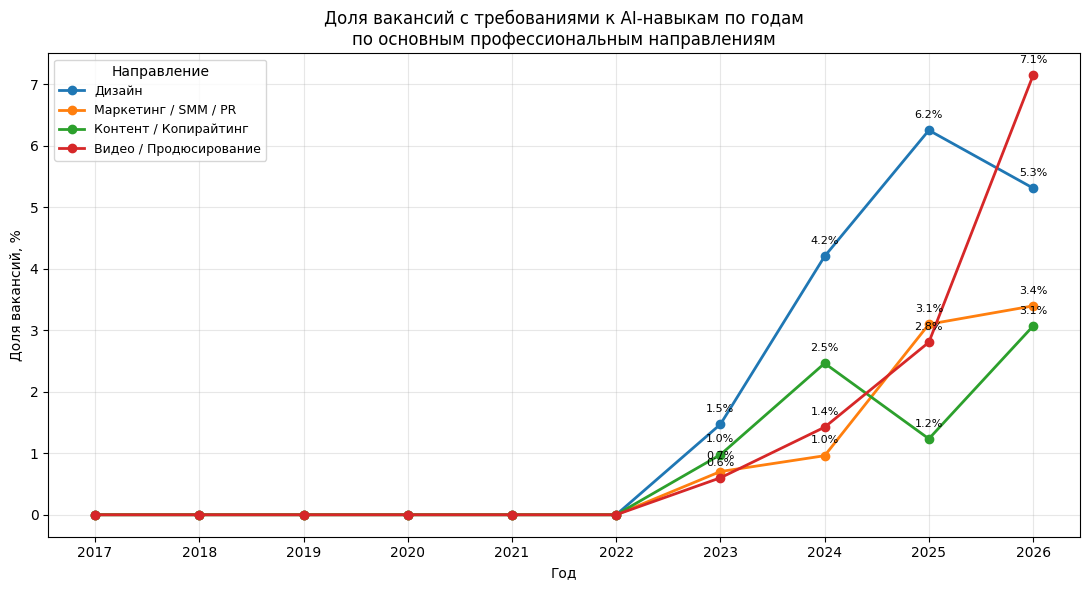

In [12]:
df = pd.read_csv(FINAL_DATASET_PATH)

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce",
    utc=True
)

df = df.dropna(subset=["date"]).copy()

df["year"] = df["date"].dt.year


profession_names = {
    "Дизайн": "Дизайн",
    "Маркетинг / SMM / PR": "Маркетинг / SMM / PR",
    "Контент / редактура / копирайтинг": "Контент / Копирайтинг",
    "Продюсирование / видео / production": "Видео / Продюсирование",
    "Администрирование / ассистенты": "Администрирование",
    "Project / product / account management": "Менеджмент",
    "Продажи / business development": "Business development",
    "IT / аналитика": "IT / аналитика",
    "HR / рекрутинг": "HR / рекрутинг",
    "Другое": "Другое"
}

df["profession_pretty"] = df["profession"].replace(profession_names)


top_professions = [
    "Дизайн",
    "Маркетинг / SMM / PR",
    "Контент / Копирайтинг",
    "Видео / Продюсирование",
]


def restore_skills(value):
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    value = str(value).strip()

    if value in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, list):
            return [
                str(skill).strip()
                for skill in parsed
                if str(skill).strip()
            ]

    except Exception:
        return []

    return []


df["skills"] = df["skills"].apply(restore_skills)


AI_SKILLS = {
    "ChatGPT",
    "GPT",
    "Claude",
    "Midjourney",
    "Stable Diffusion",
    "DALL-E",
    "Sora"
}


df["has_ai_skill"] = df["skills"].apply(
    lambda skills: any(skill in AI_SKILLS for skill in skills)
)


df_top = df[
    df["profession_pretty"].isin(top_professions)
].copy()


ai_by_year_profession = (
    df_top
    .groupby(["year", "profession_pretty"])
    .agg(
        total_vacancies=("text", "count"),
        ai_vacancies=("has_ai_skill", "sum")
    )
    .reset_index()
)

ai_by_year_profession["ai_share"] = (
    ai_by_year_profession["ai_vacancies"]
    / ai_by_year_profession["total_vacancies"]
    * 100
)


print("Доля вакансий с AI-навыками по годам и направлениям")
display(ai_by_year_profession)


fig, ax = plt.subplots(figsize=(11, 6))

for profession in top_professions:
    subset = ai_by_year_profession[
        ai_by_year_profession["profession_pretty"] == profession
    ].sort_values("year")

    ax.plot(
        subset["year"],
        subset["ai_share"],
        marker="o",
        linewidth=2,
        label=profession
    )

    for _, row in subset.iterrows():
        if row["ai_share"] > 0:
            ax.text(
                row["year"],
                row["ai_share"] + 0.2,
                f"{row['ai_share']:.1f}%",
                ha="center",
                fontsize=8
            )

ax.set_title(
    "Доля вакансий с требованиями к AI-навыкам по годам\n"
    "по основным профессиональным направлениям"
)

ax.set_xlabel("Год")
ax.set_ylabel("Доля вакансий, %")

ax.set_xticks(sorted(df_top["year"].unique()))

ax.grid(
    True,
    alpha=0.3
)

ax.legend(
    title="Направление",
    fontsize=9
)

plt.tight_layout()

plt.show()